<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/AMLBiasVarienceTradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [6]:
#generate a dataset
np.random.seed(42)
X=np.linspace(0,10,40).reshape(-1,1)

y= 2 + 0.5 * X[:,0]**2 + np.random.normal(0,5,40)

#added the noise using rand(mean, std, number of values)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

degrees=[1,2,10]

for degree in degrees:
    model=make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),LinearRegression())
    model.fit(X_train,y_train)

    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)
    y_pred=model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    train_mse=mean_squared_error(y_train,train_prediction)
    test_mse=mean_squared_error(y_test,test_prediction)

    print(f"Polynomial Degree : {degree}")
    print(f"Train MSE : {train_mse}")
    print(f"Test MSE : {test_mse}")
    print("------------------------")


Polynomial Degree : 1
Train MSE : 44.19273590495723
Test MSE : 41.82066622700546
------------------------
Polynomial Degree : 2
Train MSE : 20.07279458750202
Test MSE : 21.481193489365225
------------------------
Polynomial Degree : 10
Train MSE : 13.649341147430073
Test MSE : 25.137823993532166
------------------------


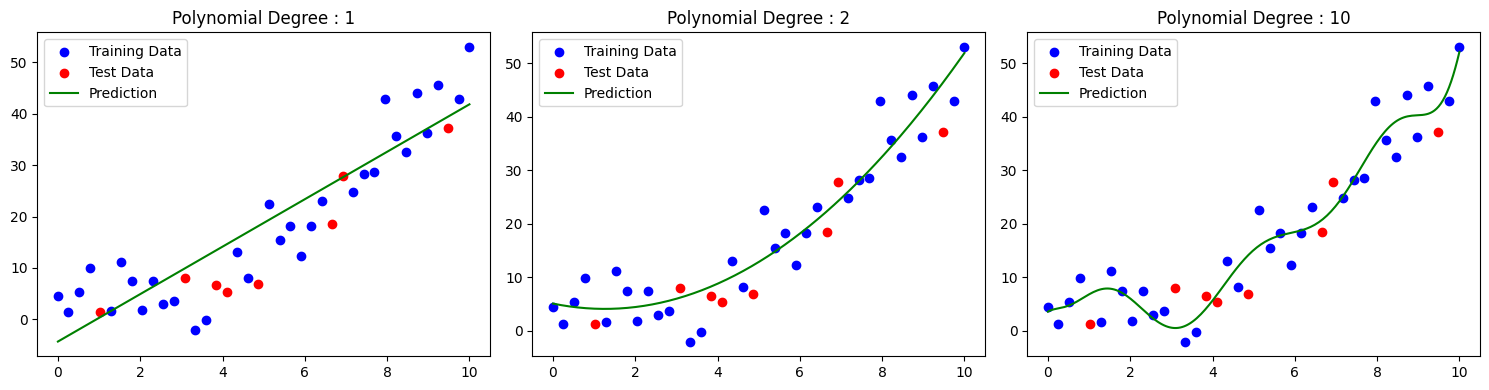

In [7]:
X_plot =np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))
for i,degree in enumerate(degrees):
    model=make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),LinearRegression())
    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,3,i+1)
    plt.scatter(X_train,y_train,color='blue',label='Training Data')
    plt.scatter(X_test,y_test,color='red',label='Test Data')
    plt.plot(X_plot,y_plot,color='green',label="Prediction")
    plt.title(f"Polynomial Degree : {degree}")
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

for degree in range(1,11):
  model=make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),LinearRegression())
  scores=cross_val_score(model,X,y,cv=5,scoring='neg_mean_squared_error')
  mean_mse=np.mean(-scores)
  print(f"Polynomial Degree : {degree}")
  print(f"Mean MSE : {mean_mse:.2f}")
  print("------------------------")

Polynomial Degree : 1
Mean MSE : 110.69
------------------------
Polynomial Degree : 2
Mean MSE : 44.22
------------------------
Polynomial Degree : 3
Mean MSE : 71.23
------------------------
Polynomial Degree : 4
Mean MSE : 82.46
------------------------
Polynomial Degree : 5
Mean MSE : 1348.27
------------------------
Polynomial Degree : 6
Mean MSE : 11392.13
------------------------
Polynomial Degree : 7
Mean MSE : 53226.76
------------------------
Polynomial Degree : 8
Mean MSE : 99956.80
------------------------
Polynomial Degree : 9
Mean MSE : 1196598.07
------------------------
Polynomial Degree : 10
Mean MSE : 11490574.52
------------------------
